## Indlæser masterdatasættet

In [36]:
import pandas as pd
import numpy as np
import os

BASE = "/Users/PC/Documents/Speciale/Analyse/Speciale"
CLEAN_DIR = os.path.join(BASE, "clean")

master = pd.read_csv(os.path.join(CLEAN_DIR, "master_monthly.csv"))
master["month"] = pd.to_datetime(master["month"])

### Regner afkast på verdensindeks (MSCI) og globalt statsobligationsindeks

In [37]:
# ============================================================
# Indeksafkast — omregn niveauer til månedsafkast
# ============================================================
# NDDUWI = globalt aktieindeks (MSCI World net TR), LGTRTRUU = globalt statsobl.
master["eq_world_ret"]  = master["NDDUWI"].pct_change()
master["bond_world_ret"] = master["LGTRTRUU"].pct_change()

# tjek
print(master[["month","NDDUWI","eq_world_ret","LGTRTRUU","bond_world_ret"]].head(3))
print(master[["eq_world_ret","bond_world_ret"]].describe())

       month    NDDUWI  eq_world_ret  LGTRTRUU  bond_world_ret
0 2015-01-31  4462.486           NaN  207.2904             NaN
1 2015-02-28  4723.937      0.058589  204.8146       -0.011944
2 2015-03-31  4649.991     -0.015653  202.7175       -0.010239
       eq_world_ret  bond_world_ret
count    138.000000      138.000000
mean       0.010039        0.000144
std        0.042481        0.019742
min       -0.132343       -0.058405
25%       -0.014541       -0.010182
50%        0.014606        0.001062
75%        0.032143        0.012441
max        0.127862        0.049404


In [38]:
# ============================================================
# Valutaafkast — harmonisér quote-retning
# Mål: "afkast på at holde fremmed valuta mod USD" for alle par
# ============================================================
# EURUSD, GBPUSD: allerede "USD per fremmed valuta" → pct_change = fremmed valutas afkast mod USD
master["eur_ret"] = master["EURUSD"].pct_change()
master["gbp_ret"] = master["GBPUSD"].pct_change()

# USDJPY, USDCHF, USDDKK: "fremmed valuta per USD" → invertér, så vi får fremmed valutas afkast mod USD
master["jpy_ret"] = (1 / master["USDJPY"]).pct_change()
master["chf_ret"] = (1 / master["USDCHF"]).pct_change()
master["dkk_ret"] = (1 / master["USDDKK"]).pct_change()

# tjek: alle skal nu betyde "fremmed valuta styrkes mod USD = positivt afkast"
fx = ["eur_ret","gbp_ret","jpy_ret","chf_ret","dkk_ret"]
print(master[fx].describe().T[["mean","std","min","max"]])
print("\nKorrelationer mellem valutaafkast:")
print(master[fx].corr().round(2))

             mean       std       min       max
eur_ret  0.000360  0.020623 -0.047167  0.053026
gbp_ret -0.000519  0.023773 -0.080922  0.055157
jpy_ret -0.001750  0.027221 -0.084222  0.077062
chf_ret  0.001190  0.022163 -0.050731  0.070840
dkk_ret  0.000329  0.020702 -0.047437  0.054023

Korrelationer mellem valutaafkast:
         eur_ret  gbp_ret  jpy_ret  chf_ret  dkk_ret
eur_ret     1.00     0.69     0.57     0.82     1.00
gbp_ret     0.69     1.00     0.28     0.53     0.69
jpy_ret     0.57     0.28     1.00     0.64     0.57
chf_ret     0.82     0.53     0.64     1.00     0.82
dkk_ret     1.00     0.69     0.57     0.82     1.00


### Log af variable

In [ ]:
# ----- Usikkerhedsindeks: log + AR(1)-stød -----
for v in ["TPU", "GPR", "VIXCLS"]:
    master[f"ln{v}"] = np.log(master[v])
    master[f"ln{v}_z"] = (master[f"ln{v}"] - master[f"ln{v}"].mean()) / master[f"ln{v}"].std()

for v in ["TPU", "GPR", "VIXCLS"]:
    lag = master[f"ln{v}"].shift(1)
    sub = master.dropna(subset=[f"ln{v}"]).index.intersection(lag.dropna().index)
    ar1 = smf.ols(f"ln{v} ~ ln{v}_lag1",
                  data=master.assign(**{f"ln{v}_lag1": lag}).loc[sub]).fit()
    master.loc[sub, f"{v}_shock"] = ar1.resid

# ----- Real aktivitet: log-difference (vækst) -----
master["ip_growth"]  = np.log(master["INDPRO"]).diff()
master["nfp_growth"] = np.log(master["PAYEMS"]).diff()

# ----- Renter: første-difference -----
master["d_DGS10"]  = master["DGS10"].diff()
master["d_us_rf"]  = master["us_rf"].diff()



### Dollarens afdækningsegenskab over tid

In [40]:
# 1) Dollarafkast: gennemsnit af USD mod de fire hovedvalutaer.
#    Vores fx-afkast er "fremmed valuta mod USD", så USD's eget afkast er MINUS det.
master["usd_ret"] = -master[["eur_ret","jpy_ret","gbp_ret","chf_ret"]].mean(axis=1)

# 2) Rullende korrelation (36 mdr) mellem dollarafkast og verdensaktieafkast
win = 36
master["corr_usd_eq"] = master["usd_ret"].rolling(win).corr(master["eq_world_ret"])

# 3) Samme mod verdensobligationer (Campbell: dollaren hedger svagt også her)
master["corr_usd_bond"] = master["usd_ret"].rolling(win).corr(master["bond_world_ret"])

print(master[["month","corr_usd_eq","corr_usd_bond"]].dropna().head(3))
print(master[["month","corr_usd_eq","corr_usd_bond"]].dropna().tail(6))

        month  corr_usd_eq  corr_usd_bond
36 2018-01-31    -0.271336      -0.744303
37 2018-02-28    -0.322441      -0.742751
38 2018-03-31    -0.293075      -0.739986
         month  corr_usd_eq  corr_usd_bond
133 2026-02-28    -0.428692      -0.903752
134 2026-03-31    -0.458857      -0.903876
135 2026-04-30    -0.476675      -0.905233
136 2026-05-31    -0.450238      -0.899797
137 2026-06-30    -0.462081      -0.899835
138 2026-07-31    -0.448545      -0.891980


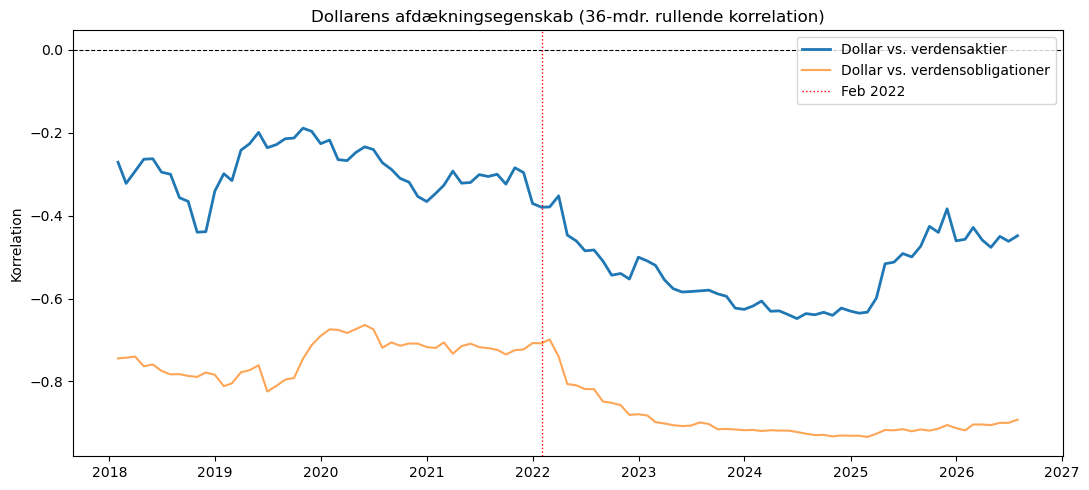

In [41]:
# PLOT: dollaren vs. verdensaktier og -obligationer
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11,5))
d = master.dropna(subset=["corr_usd_eq"])
ax.plot(d["month"], d["corr_usd_eq"], label="Dollar vs. verdensaktier", lw=2)
ax.plot(d["month"], d["corr_usd_bond"], label="Dollar vs. verdensobligationer", lw=1.5, alpha=0.7)
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.axvline(pd.Timestamp("2022-02-01"), color="red", lw=1, ls=":", label="Feb 2022")
ax.set_title(f"Dollarens afdækningsegenskab ({win}-mdr. rullende korrelation)")
ax.set_ylabel("Korrelation")
ax.legend()
plt.tight_layout()
plt.show()

### USD Hedge ratio figur

       month  USD_hedge_ratio         hr
0 2015-01-31         0.761942  76.194212
1 2015-02-28         0.732988  73.298796
2 2015-03-31         0.754138  75.413771
count    139.000000
mean      72.223943
std        5.397473
min       60.621828
25%       67.831094
50%       72.218490
75%       76.081654
max       82.117073
Name: hr, dtype: float64


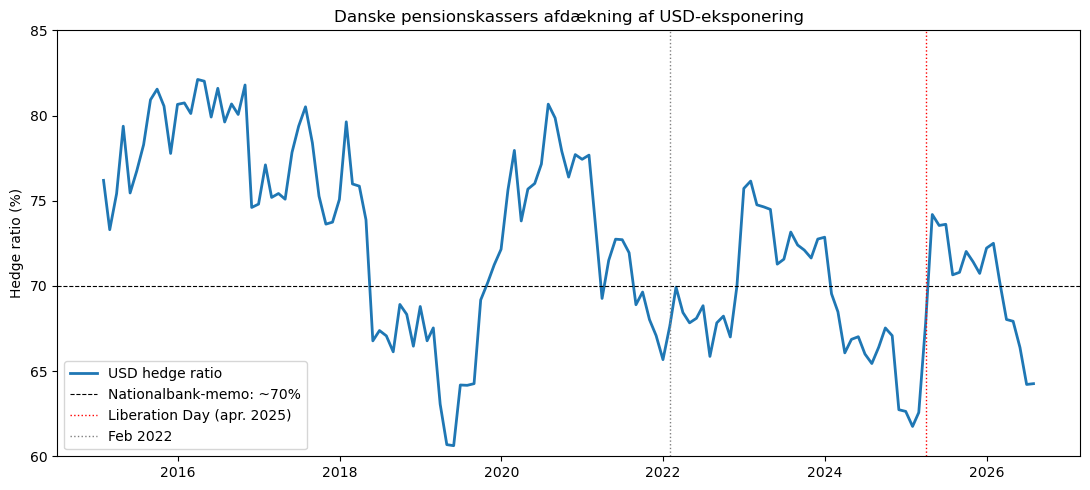

Min: 60.6%  Max: 82.1%
Jan 2025: [61.75150912] -> Apr 2025: [74.18902791]
Afdækket USD-eksponering: start (2015-01-31) = 495.3   slut (2026-07-31) = 1231.3
Uafdækket USD-eksponering: start (2015-01-31) = 154.7   slut (2026-07-31) = 684.8
Hedge ratio (%): start (2015-01-31) = 76.2   slut (2026-07-31) = 64.3


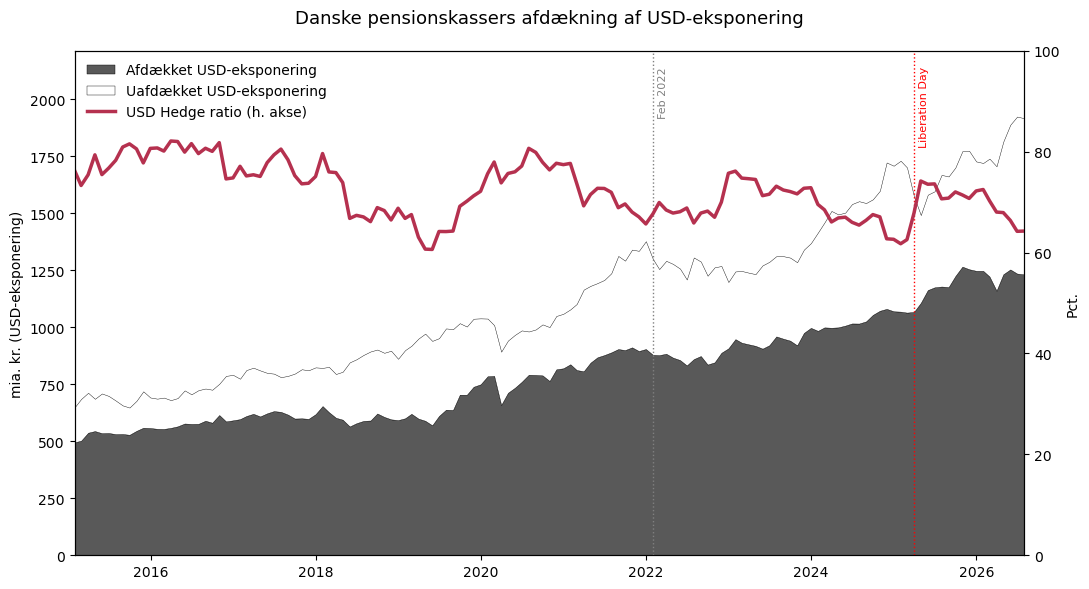

In [42]:
# ============================================================
# USD hedge ratio — er afdækningsgraden tidsvarierende?
# ============================================================
d = master.dropna(subset=["USD_hedge_ratio"]).copy()
d["hr"] = d["USD_hedge_ratio"] * 100

# tjek
print(d[["month","USD_hedge_ratio","hr"]].head(3))
print(d["hr"].describe())

fig, ax = plt.subplots(figsize=(11,5))
ax.plot(d["month"], d["hr"], lw=2, color="tab:blue", label="USD hedge ratio")
ax.set_ylim(60, 85)   # (min, max) i procent — juster tallene til det, der passer til din data
ax.axhline(70, color="black", lw=0.8, ls="--", label="Nationalbank-memo: ~70%")
ax.axvline(pd.Timestamp("2025-04-01"), color="red", lw=1, ls=":", label="Liberation Day (apr. 2025)")
ax.axvline(pd.Timestamp("2022-02-01"), color="gray", lw=1, ls=":", label="Feb 2022")

ax.set_title("Danske pensionskassers afdækning af USD-eksponering")
ax.set_ylabel("Hedge ratio (%)")
ax.legend()
plt.tight_layout()
plt.show()

# nøgletal til vejledermødet
apr25 = d.loc[d["month"] == "2025-04-30", "hr"].values
jan25 = d.loc[d["month"] == "2025-01-31", "hr"].values
print(f"Min: {d['hr'].min():.1f}%  Max: {d['hr'].max():.1f}%")
print(f"Jan 2025: {jan25} -> Apr 2025: {apr25}")

# ============================================================
# USD-eksponering: afdækket vs. uafdækket, med hedge ratio
# Efterligner Nationalbankens figur (stablet areal + linje på højre akse)
# ============================================================
d = master.dropna(subset=["USD_hedge_ratio","USD_afd_total","USD_uafd_total","USD_eksp_total"]).copy()
d["hr"] = d["USD_hedge_ratio"] * 100

fig, ax1 = plt.subplots(figsize=(11,6))

for col, navn in [("USD_afd_total", "Afdækket USD-eksponering"),
                   ("USD_uafd_total", "Uafdækket USD-eksponering"),
                   ("hr", "Hedge ratio (%)")]:
    start = d[col].iloc[0]
    slut = d[col].iloc[-1]
    print(f"{navn}: start ({d['month'].iloc[0].date()}) = {start:.1f}   "
          f"slut ({d['month'].iloc[-1].date()}) = {slut:.1f}")

# Stablet areal: afdækket (mørkegrå) nederst, uafdækket (hvid) ovenpå
ax1.stackplot(
    d["month"],
    d["USD_afd_total"], d["USD_uafd_total"],
    labels=["Afdækket USD-eksponering", "Uafdækket USD-eksponering"],
    colors=["#595959", "white"],
    edgecolor="black", linewidth=0.3,
)
ax1.set_ylabel("mia. kr. (USD-eksponering)")
ax1.set_ylim(0, d["USD_eksp_total"].max() * 1.15)
ax1.set_xlim(pd.Timestamp("2015-01-31"), pd.Timestamp("2026-07-31"))

# Hedge ratio på højre akse
ax2 = ax1.twinx()
ax2.plot(d["month"], d["hr"], color="#b5314f", lw=2.5, label="USD Hedge ratio (h. akse)")
ax2.set_ylabel("Pct.")
ax2.set_ylim(0, 100)  # juster til dataens variation

# Marker Liberation Day
offset = pd.Timedelta(days=20)

ax1.axvline(pd.Timestamp("2025-04-01"), color="red", lw=1, ls=":")
ax1.text(pd.Timestamp("2025-04-01") + offset, ax1.get_ylim()[1]*0.97, "Liberation Day",
         color="red", fontsize=8, rotation=90, va="top", ha="left")

ax1.axvline(pd.Timestamp("2022-02-01"), color="gray", lw=1, ls=":")
ax1.text(pd.Timestamp("2022-02-01") + offset, ax1.get_ylim()[1]*0.97, "Feb 2022",
         color="gray", fontsize=8, rotation=90, va="top", ha="left")

ax1.set_title("Danske pensionskassers afdækning af USD-eksponering", fontsize=13, loc="center", pad=20)
# Fælles legend for begge akser
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", frameon=False)

plt.tight_layout()
plt.show()

# LP-Projections - TPU 

In [49]:
from scipy import stats

H = 18
LP_LAGS = 2
NW_LAG = H

d = master.copy().sort_values("month").reset_index(drop=True)
d["hr"] = d["USD_hedge_ratio"] * 100

# Standardisér stødet -> koefficient tolkes som pp pr. 1 std.afv. TPU-stød
d["TPU_shock_z"] = (d["TPU_shock"] - d["TPU_shock"].mean()) / d["TPU_shock"].std()

# nfp_growth droppet (overlapper ip_growth); stationære kontroller jf. Jordà
kontroller = ["ip_growth", "inflation", "d_DGS10"]

lag_termer = []
for var in kontroller + ["TPU_shock_z"]:
    for L in range(1, LP_LAGS + 1):
        col = f"{var}_l{L}"
        d[col] = d[var].shift(L)
        lag_termer.append(col)
kontrol_formel = " + ".join(lag_termer)

resultater = []
for h in range(H + 1):
    d[f"hr_lead{h}"] = d["hr"].shift(-h) - d["hr"].shift(1)
    sub = d.dropna(subset=[f"hr_lead{h}", "TPU_shock_z"] + lag_termer)

    m = smf.ols(f"hr_lead{h} ~ TPU_shock_z + {kontrol_formel}",
                data=sub).fit(cov_type="HAC", cov_kwds={"maxlags": NW_LAG})

    resultater.append({"h": h,
                       "coef": m.params["TPU_shock_z"],
                       "se":   m.bse["TPU_shock_z"],
                       "n":    int(m.nobs)})

# Byg dataframe + konfidensbånd
lp = pd.DataFrame(resultater)
lp["ci68_low"], lp["ci68_high"] = lp["coef"] - lp["se"],      lp["coef"] + lp["se"]
lp["ci95_low"], lp["ci95_high"] = lp["coef"] - 1.96*lp["se"], lp["coef"] + 1.96*lp["se"]

# Signifikans
lp["t"] = lp["coef"] / lp["se"]
lp["p"] = 2 * (1 - stats.norm.cdf(lp["t"].abs()))
lp["sig"] = np.where(lp["p"] < 0.05, "**",
             np.where(lp["p"] < 0.10, "*",
             np.where(lp["t"].abs() > 1, "(68%)", "")))
print(lp[["h","coef","se","t","p","sig"]].round(3).to_string(index=False))

 h   coef    se      t     p   sig
 0  0.204 0.228  0.895 0.371      
 1  0.326 0.445  0.733 0.463      
 2  0.003 0.552  0.006 0.995      
 3 -0.030 0.489 -0.062 0.950      
 4  0.108 0.505  0.214 0.830      
 5  0.320 0.587  0.545 0.586      
 6  0.740 0.494  1.498 0.134 (68%)
 7  0.904 0.483  1.872 0.061     *
 8  0.815 0.568  1.433 0.152 (68%)
 9  0.821 0.571  1.436 0.151 (68%)
10  0.511 0.598  0.855 0.392      
11  0.635 0.558  1.138 0.255 (68%)
12  0.709 0.581  1.220 0.222 (68%)
13  0.744 0.667  1.116 0.264 (68%)
14  0.926 0.589  1.574 0.115 (68%)
15  0.959 0.487  1.970 0.049    **
16  0.840 0.533  1.578 0.115 (68%)
17  0.983 0.599  1.642 0.101 (68%)
18  0.682 0.736  0.927 0.354      


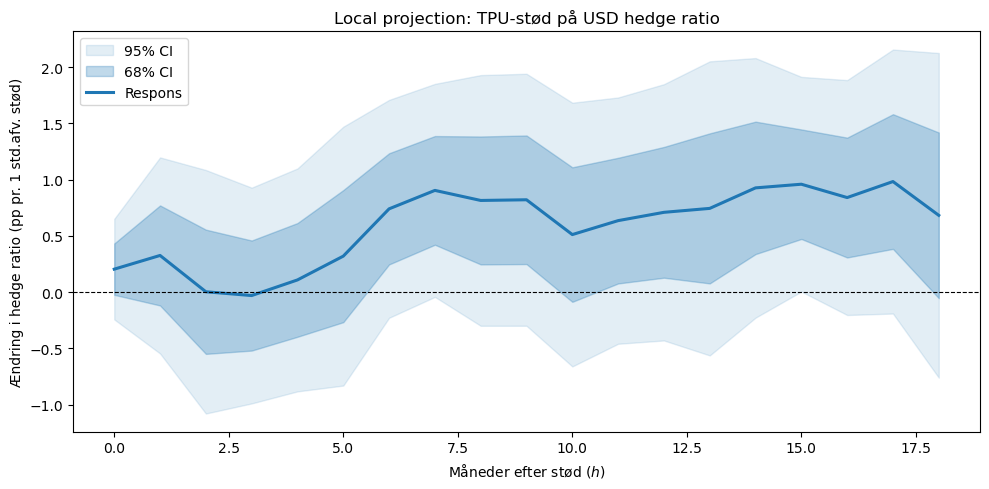

In [50]:
fig, ax = plt.subplots(figsize=(10,5))
ax.fill_between(lp["h"], lp["ci95_low"], lp["ci95_high"], color="tab:blue", alpha=0.12, label="95% CI")
ax.fill_between(lp["h"], lp["ci68_low"], lp["ci68_high"], color="tab:blue", alpha=0.28, label="68% CI")
ax.plot(lp["h"], lp["coef"], color="tab:blue", lw=2.2, label="Respons")
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.set_xlabel("Måneder efter stød ($h$)")
ax.set_ylabel("Ændring i hedge ratio (pp pr. 1 std.afv. stød)")
ax.set_title("Local projection: TPU-stød på USD hedge ratio")
ax.legend()
plt.tight_layout()
plt.show()

# LP-Projections - GPR

In [51]:
from scipy import stats

H = 18
LP_LAGS = 2
NW_LAG = H

d = master.copy().sort_values("month").reset_index(drop=True)
d["hr"] = d["USD_hedge_ratio"] * 100

# Standardisér GPR-stødet
d["GPR_shock_z"] = (d["GPR_shock"] - d["GPR_shock"].mean()) / d["GPR_shock"].std()

kontroller = ["ip_growth", "inflation", "d_DGS10"]

lag_termer = []
for var in kontroller + ["GPR_shock_z"]:
    for L in range(1, LP_LAGS + 1):
        col = f"{var}_l{L}"
        d[col] = d[var].shift(L)
        lag_termer.append(col)
kontrol_formel = " + ".join(lag_termer)

resultater = []
for h in range(H + 1):
    d[f"hr_lead{h}"] = d["hr"].shift(-h) - d["hr"].shift(1)
    sub = d.dropna(subset=[f"hr_lead{h}", "GPR_shock_z"] + lag_termer)

    m = smf.ols(f"hr_lead{h} ~ GPR_shock_z + {kontrol_formel}",
                data=sub).fit(cov_type="HAC", cov_kwds={"maxlags": NW_LAG})

    resultater.append({"h": h,
                       "coef": m.params["GPR_shock_z"],
                       "se":   m.bse["GPR_shock_z"],
                       "n":    int(m.nobs)})

lp_gpr = pd.DataFrame(resultater)
lp_gpr["ci68_low"], lp_gpr["ci68_high"] = lp_gpr["coef"] - lp_gpr["se"],      lp_gpr["coef"] + lp_gpr["se"]
lp_gpr["ci95_low"], lp_gpr["ci95_high"] = lp_gpr["coef"] - 1.96*lp_gpr["se"], lp_gpr["coef"] + 1.96*lp_gpr["se"]

lp_gpr["t"] = lp_gpr["coef"] / lp_gpr["se"]
lp_gpr["p"] = 2 * (1 - stats.norm.cdf(lp_gpr["t"].abs()))
lp_gpr["sig"] = np.where(lp_gpr["p"] < 0.05, "**",
                 np.where(lp_gpr["p"] < 0.10, "*",
                 np.where(lp_gpr["t"].abs() > 1, "(68%)", "")))
print(lp_gpr[["h","coef","se","t","p","sig"]].round(3).to_string(index=False))

 h   coef    se      t     p   sig
 0  0.070 0.122  0.578 0.563      
 1  0.325 0.253  1.285 0.199 (68%)
 2 -0.049 0.247 -0.199 0.842      
 3 -0.122 0.321 -0.380 0.704      
 4 -0.043 0.317 -0.135 0.893      
 5  0.215 0.391  0.549 0.583      
 6  0.534 0.384  1.392 0.164 (68%)
 7  0.521 0.466  1.118 0.264 (68%)
 8  0.377 0.485  0.778 0.437      
 9  0.409 0.420  0.974 0.330      
10  0.637 0.508  1.254 0.210 (68%)
11  0.710 0.500  1.419 0.156 (68%)
12  0.505 0.662  0.762 0.446      
13  0.379 0.711  0.533 0.594      
14  0.256 0.546  0.468 0.640      
15  0.383 0.583  0.658 0.511      
16  0.503 0.615  0.817 0.414      
17  0.478 0.572  0.835 0.404      
18  0.979 0.440  2.226 0.026    **


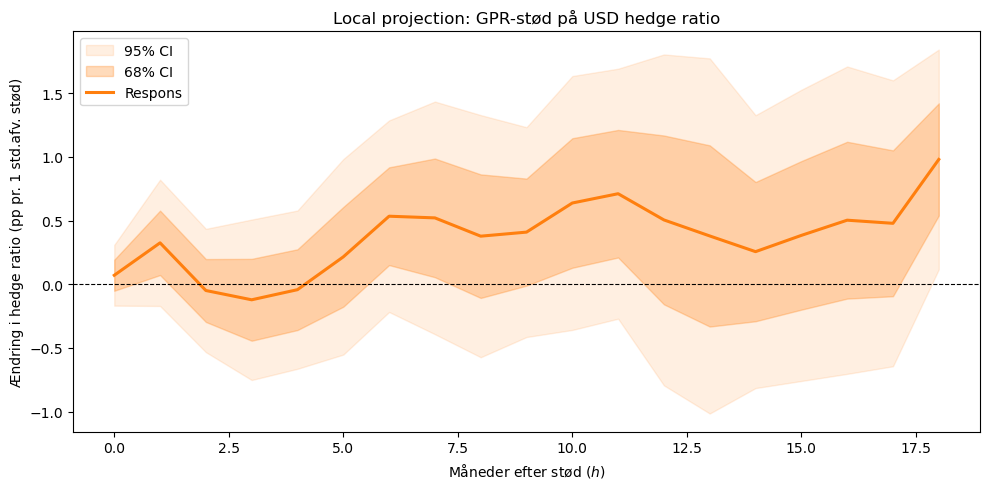

In [52]:
fig, ax = plt.subplots(figsize=(10,5))
ax.fill_between(lp_gpr["h"], lp_gpr["ci95_low"], lp_gpr["ci95_high"], color="tab:orange", alpha=0.12, label="95% CI")
ax.fill_between(lp_gpr["h"], lp_gpr["ci68_low"], lp_gpr["ci68_high"], color="tab:orange", alpha=0.28, label="68% CI")
ax.plot(lp_gpr["h"], lp_gpr["coef"], color="tab:orange", lw=2.2, label="Respons")
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.set_xlabel("Måneder efter stød ($h$)")
ax.set_ylabel("Ændring i hedge ratio (pp pr. 1 std.afv. stød)")
ax.set_title("Local projection: GPR-stød på USD hedge ratio")
ax.legend()
plt.tight_layout()
plt.show()